# Box-Benhken example with synthetic data

In [1]:
# ==============================================================================
# HEK293 Transient Transfection: Box-Behnken Design Modeling & Optimization
# ==============================================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import minimize
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# ==============================================================================
# Step 1: Data Ingestion (Using the provided template)
# ==============================================================================
print("Loading Experimental Matrix Template...")

# Load the layout from the provided CSV template
# Ensure the file is in the same working directory as this notebook
file_path = 'HEK293_Transfection_DoE_Layout.xlsx'
df_master = pd.read_excel(file_path)

display(df_master)

Loading Experimental Matrix Template...


,Unnamed: 0,pDNA_concentration,DNA_FectoPro_ratio,FectoPro_Booster,pDNA_concentration_scaled,DNA_FectoPro_ratio_scaled,FectoPro_Booster_scaled,Type,Cell type,mAb_Titer_mg_mL,VCD_Harvest_cells_mL,Viability_Percent
0,0,0.8,0.4,0.0,0.0,-1.0,-1.0,BBD_Run,HEK P70-1,NaN,NaN,NaN
1,1,0.8,1.0,0.5,NaN,NaN,NaN,Baseline_Control,HEK-SUS,NaN,NaN,NaN
2,2,0.4,0.4,0.5,-1.0,-1.0,0.0,BBD_Run,HEK P70-1,NaN,NaN,NaN
3,3,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK P70-1,NaN,NaN,NaN
4,4,0.8,1.2,1.0,0.0,1.0,1.0,BBD_Run,HEK P70-1,NaN,NaN,NaN
5,5,0.8,0.4,1.0,0.0,-1.0,1.0,BBD_Run,HEK P70-1,NaN,NaN,NaN
6,6,0.8,0.8,0.5,0.0,0.0,0.0,BBD_Run,HEK P70-1,NaN,NaN,NaN
7,7,0.4,1.2,0.5,-1.0,1.0,0.0,BBD_Run,HEK P70-1,NaN,NaN,NaN
8,8,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK-SUS,NaN,NaN,NaN
9,9,0.4,0.8,1.0,-1.0,0.0,1.0,BBD_Run,HEK P70-1,NaN,NaN,NaN


In [3]:
# ==============================================================================
# Step 2: In-Silico Data Simulation (Filling the Template)
# ==============================================================================
def simulate_cqa(row):
    """Generates Titer, VCD, and Viability based on phenomenological equations."""
    x1, x2, x3 = row['pDNA_concentration'], row['DNA_FectoPro_ratio'], row['FectoPro_Booster']
    
    # 1. Negative Control Handling
    if row['Type'] == 'Negative_Control':
        titer = max(0, np.random.normal(0.0, 0.01))
        vcd = np.random.normal(8.0, 0.3)
        viab = min(100, np.random.normal(95.0, 1.0))
        return pd.Series([titer, vcd, viab])
    
    # 2. Volumetric Titer (Parabolic peak near 1.0, 0.9, 0.6)
    t_base = 1.5 - 2.0*(x1 - 1.0)**2 - 2.5*(x2 - 0.9)**2 - 1.5*(x3 - 0.6)**2 + 0.8*(x1 - 1.0)*(x2 - 0.9)
    titer = max(0, t_base + np.random.normal(0, 0.08))
    
    # 3. VCD (Uninhibited reaches ~6.0. High booster and ratio penalize)
    v_base = 6.0 - 1.2*x3 - 0.8*(x3)**2 - 1.0*(x2 - 0.4)**2
    vcd = max(0.5, v_base + np.random.normal(0, 0.3))
    
    # 4. Viability (Toxicity threshold > 0.7 for booster)
    toxicity_penalty = 60 * max(0, x3 - 0.7)**2
    viab_base = 95.0 - toxicity_penalty
    viab = min(100, max(0, viab_base + np.random.normal(0, 2.5)))
    
    return pd.Series([titer, vcd, viab])

# Apply simulation using a seed for reproducibility
np.random.seed(42)
df_master[['mAb_Titer_mg_mL', 'VCD_Harvest_cells_mL', 'Viability_Percent']] = df_master.apply(simulate_cqa, axis=1)

print("\nSimulated Data Populated (First 5 Rows):")
display(df_master)


Simulated Data Populated (First 5 Rows):


,Unnamed: 0,pDNA_concentration,DNA_FectoPro_ratio,FectoPro_Booster,pDNA_concentration_scaled,DNA_FectoPro_ratio_scaled,FectoPro_Booster_scaled,Type,Cell type,mAb_Titer_mg_mL,VCD_Harvest_cells_mL,Viability_Percent
0,0,0.8,0.4,0.0,0.0,-1.0,-1.0,BBD_Run,HEK P70-1,0.374737,5.958521,96.619221
1,1,0.8,1.0,0.5,NaN,NaN,NaN,Baseline_Control,HEK-SUS,1.485842,4.769754,94.414658
2,2,0.4,0.4,0.5,-1.0,-1.0,0.0,BBD_Run,HEK P70-1,0.506337,5.430230,93.826314
3,3,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK P70-1,0.005426,7.860975,94.534270
4,4,0.8,1.2,1.0,0.0,1.0,1.0,BBD_Run,HEK P70-1,0.926357,2.786016,85.287705
5,5,0.8,0.4,1.0,0.0,-1.0,1.0,BBD_Run,HEK P70-1,0.590017,3.696151,90.385618
6,6,0.8,0.8,0.5,0.0,0.0,0.0,BBD_Run,HEK P70-1,1.323358,4.616309,98.664122
7,7,0.4,1.2,0.5,-1.0,1.0,0.0,BBD_Run,HEK P70-1,0.377938,4.580258,91.438130
8,8,0.0,0.0,0.0,NaN,NaN,NaN,Negative_Control,HEK-SUS,0.000000,8.033277,93.849006
9,9,0.4,0.8,1.0,-1.0,0.0,1.0,BBD_Run,HEK P70-1,0.593056,3.659808,88.870766


In [4]:
# ==============================================================================
# Step 3: Data Preparation & Statistical Pre-processing
# ==============================================================================
# Isolate the BBD runs for orthogonal RSM modeling (Exclude controls)
df_model = df_master[df_master['Type'] == 'BBD_Run'].copy()
df_controls = df_master[df_master['Type'] != 'BBD_Run'].copy()

# Normality Check on Simulated CQAs (Shapiro-Wilk)
print("\nShapiro-Wilk Normality Test (BBD Runs Only):")
for cqa in ['mAb_Titer_mg_mL', 'VCD_Harvest_cells_mL', 'Viability_Percent']:
    stat, p_val = stats.shapiro(df_model[cqa])
    print(f" - {cqa}: W={stat:.3f}, p-value={p_val:.3f} " 
          f"({'Normal' if p_val > 0.05 else 'Non-Normal'})")


Shapiro-Wilk Normality Test (BBD Runs Only):
 - mAb_Titer_mg_mL: W=0.898, p-value=0.088 (Normal)
 - VCD_Harvest_cells_mL: W=0.914, p-value=0.157 (Normal)
 - Viability_Percent: W=0.954, p-value=0.592 (Normal)


In [5]:
df_model

,Unnamed: 0,pDNA_concentration,DNA_FectoPro_ratio,FectoPro_Booster,pDNA_concentration_scaled,DNA_FectoPro_ratio_scaled,FectoPro_Booster_scaled,Type,Cell type,mAb_Titer_mg_mL,VCD_Harvest_cells_mL,Viability_Percent
0,0,0.8,0.4,0.0,0.0,-1.0,-1.0,BBD_Run,HEK P70-1,0.374737,5.958521,96.619221
2,2,0.4,0.4,0.5,-1.0,-1.0,0.0,BBD_Run,HEK P70-1,0.506337,5.430230,93.826314
4,4,0.8,1.2,1.0,0.0,1.0,1.0,BBD_Run,HEK P70-1,0.926357,2.786016,85.287705
5,5,0.8,0.4,1.0,0.0,-1.0,1.0,BBD_Run,HEK P70-1,0.590017,3.696151,90.385618
6,6,0.8,0.8,0.5,0.0,0.0,0.0,BBD_Run,HEK P70-1,1.323358,4.616309,98.664122
7,7,0.4,1.2,0.5,-1.0,1.0,0.0,BBD_Run,HEK P70-1,0.377938,4.580258,91.438130
9,9,0.4,0.8,1.0,-1.0,0.0,1.0,BBD_Run,HEK P70-1,0.593056,3.659808,88.870766
10,10,1.2,0.4,0.5,1.0,-1.0,0.0,BBD_Run,HEK P70-1,0.651863,5.755683,94.966257
11,11,0.8,0.8,0.5,0.0,0.0,0.0,BBD_Run,HEK P70-1,1.311383,5.286763,91.947891
13,13,1.2,1.2,0.5,1.0,1.0,0.0,BBD_Run,HEK P70-1,1.243749,4.781540,95.428421


## Test the `RSM_reduction_optimizer` class
The class automates the iterative removal of the least significant terms ($p > 0.05$), records the statistical performance (AIC, BIC, Adjusted $R^2$) at each step, and returns both the tracking table and the final optimized model. It also follows the **Principle of Marginality**.



In [6]:
# Call the dependency
from RSM_reduction_optimizer import RSMModelEvaluator as rsm


In [7]:
# Define the full quadratic terms for 3 factors
rsm_terms = [
    # Main Effects:
    "pDNA_concentration_scaled", 
    "DNA_FectoPro_ratio_scaled", 
    "FectoPro_Booster_scaled",
    
    # Quadratic Terms:
    "I(pDNA_concentration_scaled**2)", 
    "I(DNA_FectoPro_ratio_scaled**2)", 
    "I(FectoPro_Booster_scaled**2)",

    # 2-Way Interactions
    "pDNA_concentration_scaled:DNA_FectoPro_ratio_scaled",
    "pDNA_concentration_scaled:FectoPro_Booster_scaled",
    "DNA_FectoPro_ratio_scaled:FectoPro_Booster_scaled"
]

In [8]:
# Run optimization
evaluator_viab = rsm(data=df_model, target_col='Viability_Percent', initial_terms=rsm_terms, alpha=0.05)
viab_history = evaluator_viab.fit_stepwise()

In [9]:
# 1. Review the history to make a decision
print("Candidate Models:")
display(viab_history)

Candidate Models:


,Iteration,Removed_Term,R_squared,Adj_R_squared,AIC,BIC,Max_P_Value
0,0,None (Full Model),0.7990,0.4372,77.97,85.05,0.9068
1,1,DNA_FectoPro_ratio_scaled:FectoPro_Booster_scaled,0.7984,0.5296,76.01,82.38,0.7848
2,2,I(pDNA_concentration_scaled**2),0.7957,0.5913,74.21,79.88,0.5814
3,3,pDNA_concentration_scaled:DNA_FectoPro_ratio_s...,0.7859,0.6254,72.91,77.87,0.3815
4,4,pDNA_concentration_scaled:FectoPro_Booster_scaled,0.7630,0.6313,72.44,76.69,0.1350
5,5,I(DNA_FectoPro_ratio_scaled**2),0.6919,0.5687,74.37,77.91,0.1424
6,6,DNA_FectoPro_ratio_scaled,0.6138,0.5085,75.76,78.59,0.0627
7,7,pDNA_concentration_scaled,0.4633,0.3738,78.70,80.82,0.0815
8,8,I(FectoPro_Booster_scaled**2),0.3016,0.2479,80.65,82.06,0.0340


In [10]:
# 2. Extract the model that performs best (e.g., Iteration 4)
best_viability_model = evaluator_viab.get_model(iteration_index=4)

In [11]:
# View its specific summary or use it for predictions
display(best_viability_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Viability_Percent   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     5.794
Date:                Thu, 09 Jul 2026   Prob (F-statistic):             0.0115
Time:                        14:40:23   Log-Likelihood:                -30.220
No. Observations:                  15   AIC:                             72.44
Df Residuals:                       9   BIC:                             76.69
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            96.0922      1.125     85.399      0.000      93.547      98.638
pDNA_concentration_scaled             1.9800      0.828      2.391      0.040       0.107       3.853
DNA_FectoPro_ratio_scaled            -1.4261      0.828     -1.722      0.119      -3.300       0.447
FectoPro_Booster_scaled              -2.8024      0.828     -3.384      0.008      -4.676      -0.929
I(DNA_FectoPro_ratio_scaled ** 2)    -1.9959      1.215     -1.642      0.135      -4.745       0.753
I(FectoPro_Booster_scaled ** 2)      -3.1461      1.215     -2.589      0.029      -5.895      -0.397
==============================================================================
Omnibus:                        2.540   Durbin-Watson:                   1.547
Prob(Omnibus):                  0.281   Jarque-Bera (JB):                1.553
Skew:                          -0.782   Prob(JB):                        0.460
Kurtosis:                       2.808   Cond. No.                         3.45
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
# Run evaluator
evaluator_titer = rsm(data=df_model, target_col='mAb_Titer_mg_mL', initial_terms=rsm_terms, alpha=0.05)
titer_history = evaluator_titer.fit_stepwise()

In [13]:
# 1. Review the history to make a decision
print("Candidate titer Models:")
display(titer_history)

Candidate titer Models:


,Iteration,Removed_Term,R_squared,Adj_R_squared,AIC,BIC,Max_P_Value
0,0,None (Full Model),0.9989,0.9970,-70.21,-63.13,0.7762
1,1,pDNA_concentration_scaled:FectoPro_Booster_scaled,0.9989,0.9975,-71.95,-65.57,0.0097


In [14]:
# 2. Extract the model that performs best (e.g., Iteration 1)
best_titer_model = evaluator_titer.get_model(iteration_index=1)
best_titer_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        mAb_Titer_mg_mL   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     686.9
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           2.59e-08
Time:                        14:40:26   Log-Likelihood:                 44.973
No. Observations:                  15   AIC:                            -71.95
Df Residuals:                       6   BIC:                            -65.57
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================================================
                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                                               1.3117      0.011    119.061      0.000       1.285       1.339
pDNA_concentration_scaled                               0.2583      0.007     38.283      0.000       0.242       0.275
DNA_FectoPro_ratio_scaled                               0.1242      0.007     18.413      0.000       0.108       0.141
FectoPro_Booster_scaled                                 0.1549      0.007     22.959      0.000       0.138       0.171
I(pDNA_concentration_scaled ** 2)                      -0.2723      0.010    -27.418      0.000      -0.297      -0.248
I(DNA_FectoPro_ratio_scaled ** 2)                      -0.3444      0.010    -34.685      0.000      -0.369      -0.320
I(FectoPro_Booster_scaled ** 2)                        -0.3523      0.010    -35.476      0.000      -0.377      -0.328
pDNA_concentration_scaled:DNA_FectoPro_ratio_scaled     0.1801      0.010     18.874      0.000       0.157       0.203
DNA_FectoPro_ratio_scaled:FectoPro_Booster_scaled       0.0356      0.010      3.732      0.010       0.012       0.059
==============================================================================
Omnibus:                        0.816   Durbin-Watson:                   2.096
Prob(Omnibus):                  0.665   Jarque-Bera (JB):                0.686
Skew:                          -0.175   Prob(JB):                        0.710
Kurtosis:                       2.012   Cond. No.                         4.24
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
# Run evaluator
evaluator_vcd = rsm(data=df_model, target_col='VCD_Harvest_cells_mL', initial_terms=rsm_terms, alpha=0.05)
vcd_history = evaluator_vcd.fit_stepwise()

In [16]:
# 1. Review the history to make a decision
print("Candidate titer Models:")
display(vcd_history)

Candidate titer Models:


,Iteration,Removed_Term,R_squared,Adj_R_squared,AIC,BIC,Max_P_Value
0,0,None (Full Model),0.9718,0.9211,6.84,13.92,0.8870
1,1,pDNA_concentration_scaled:FectoPro_Booster_scaled,0.9717,0.9339,4.90,11.28,0.8101
2,2,pDNA_concentration_scaled:DNA_FectoPro_ratio_s...,0.9714,0.9428,3.06,8.72,0.5955
3,3,DNA_FectoPro_ratio_scaled:FectoPro_Booster_scaled,0.9701,0.9477,1.71,6.66,0.2082
4,4,I(DNA_FectoPro_ratio_scaled**2),0.9631,0.9426,2.87,7.11,0.1574
5,5,I(pDNA_concentration_scaled**2),0.9461,0.9246,6.55,10.09,0.2083
6,6,pDNA_concentration_scaled,0.9364,0.9191,7.04,9.88,0.0065


In [17]:
display(evaluator_vcd.get_model(iteration_index=3).summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     VCD_Harvest_cells_mL   R-squared:                       0.970
Model:                              OLS   Adj. R-squared:                  0.948
Method:                   Least Squares   F-statistic:                     43.30
Date:                  Thu, 09 Jul 2026   Prob (F-statistic):           1.14e-05
Time:                          14:40:28   Log-Likelihood:                 6.1458
No. Observations:                    15   AIC:                             1.708
Df Residuals:                         8   BIC:                             6.665
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             5.0623      0.127     39.864      0.000       4.769       5.355
pDNA_concentration_scaled             0.1256      0.078      1.616      0.145      -0.054       0.305
DNA_FectoPro_ratio_scaled            -0.4236      0.078     -5.447      0.001      -0.603      -0.244
FectoPro_Booster_scaled              -1.1099      0.078    -14.273      0.000      -1.289      -0.931
I(pDNA_concentration_scaled ** 2)     0.2314      0.114      2.021      0.078      -0.033       0.495
I(DNA_FectoPro_ratio_scaled ** 2)    -0.1567      0.114     -1.369      0.208      -0.421       0.107
I(FectoPro_Booster_scaled ** 2)      -0.4693      0.114     -4.100      0.003      -0.733      -0.205
==============================================================================
Omnibus:                        7.589   Durbin-Watson:                   1.593
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                4.152
Skew:                          -1.003   Prob(JB):                        0.125
Kurtosis:                       4.617   Cond. No.                         4.24
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
# 2. Extract the model that performs best (e.g., Iteration 3)
best_vcd_model = evaluator_vcd.get_model(iteration_index=3)
best_vcd_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     VCD_Harvest_cells_mL   R-squared:                       0.970
Model:                              OLS   Adj. R-squared:                  0.948
Method:                   Least Squares   F-statistic:                     43.30
Date:                  Thu, 09 Jul 2026   Prob (F-statistic):           1.14e-05
Time:                          14:40:40   Log-Likelihood:                 6.1458
No. Observations:                    15   AIC:                             1.708
Df Residuals:                         8   BIC:                             6.665
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             5.0623      0.127     39.864      0.000       4.769       5.355
pDNA_concentration_scaled             0.1256      0.078      1.616      0.145      -0.054       0.305
DNA_FectoPro_ratio_scaled            -0.4236      0.078     -5.447      0.001      -0.603      -0.244
FectoPro_Booster_scaled              -1.1099      0.078    -14.273      0.000      -1.289      -0.931
I(pDNA_concentration_scaled ** 2)     0.2314      0.114      2.021      0.078      -0.033       0.495
I(DNA_FectoPro_ratio_scaled ** 2)    -0.1567      0.114     -1.369      0.208      -0.421       0.107
I(FectoPro_Booster_scaled ** 2)      -0.4693      0.114     -4.100      0.003      -0.733      -0.205
==============================================================================
Omnibus:                        7.589   Durbin-Watson:                   1.593
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                4.152
Skew:                          -1.003   Prob(JB):                        0.125
Kurtosis:                       4.617   Cond. No.                         4.24
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

=== MULTI-OBJECTIVE OPTIMIZATION SUCCESS ===
Optimal Conditions: pDNA=1.036 µg/mL, Ratio=0.939 µg/µL, Booster=0.619 µL/mL
Predicted CQAs: Titer=1.428 mg/mL, VCD=4.760, Viability=95.7%



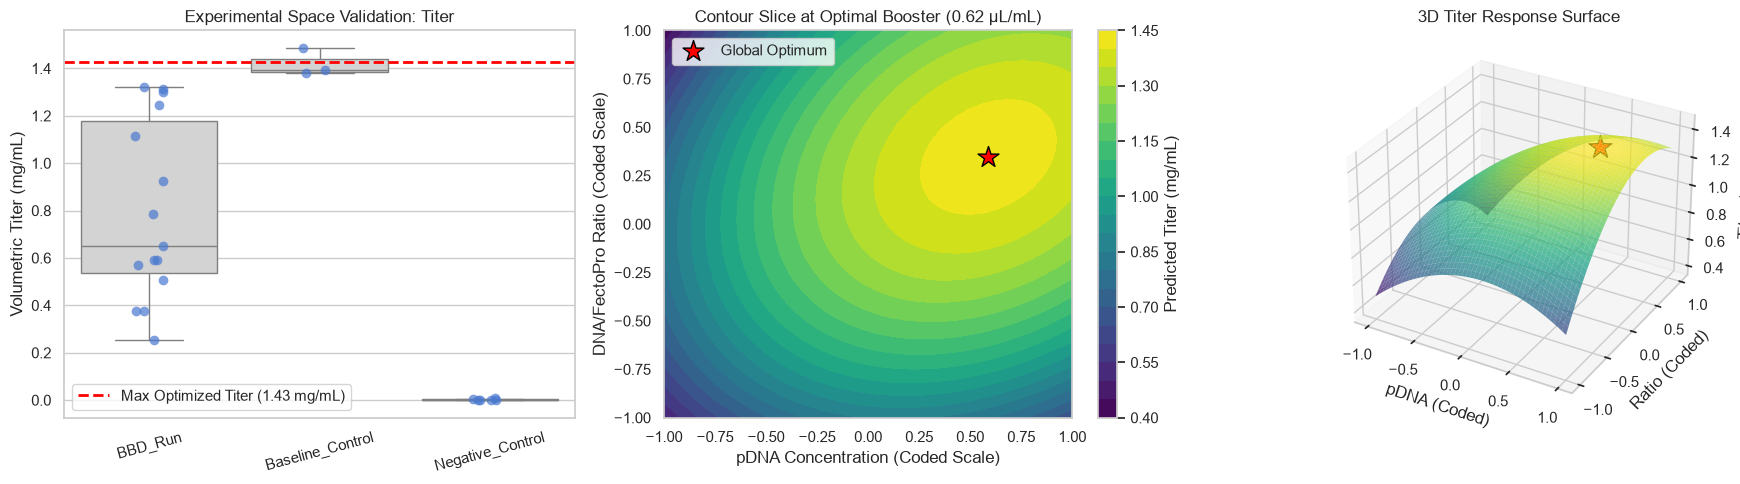

In [25]:
# ==============================================================================
# Step 5 & 6: Optimization and Enhanced Visualizations
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize

# 1. SETUP MODELS FOR OPTIMIZATION
best_vcd_model = evaluator_vcd.get_model(iteration_index=3)

models_evaluation = {
    'mAb_Titer_mg_mL': best_titer_model,
    'VCD_Harvest_cells_mL': best_vcd_model,
    'Viability_Percent': best_viability_model
}

def predict_responses(x):
    x_df = pd.DataFrame([{
        'pDNA_concentration_scaled': x[0], 
        'DNA_FectoPro_ratio_scaled': x[1], 
        'FectoPro_Booster_scaled': x[2]
    }])
    t = models_evaluation['mAb_Titer_mg_mL'].predict(x_df).iloc[0]
    v = models_evaluation['VCD_Harvest_cells_mL'].predict(x_df).iloc[0]
    vi = models_evaluation['Viability_Percent'].predict(x_df).iloc[0]
    return t, v, vi

def objective(x):
    t, _, _ = predict_responses(x)
    return -t  # Maximize titer by minimizing negative titer

# Multi-objective constraints
constraints = (
    {'type': 'ineq', 'fun': lambda x: predict_responses(x)[1] - 3.5},  # VCD >= 3.5
    {'type': 'ineq', 'fun': lambda x: predict_responses(x)[2] - 75.0}  # Viability >= 75%
)

bounds = [(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)]
x0 = [0.0, 0.0, 0.0]

# Run the optimization
result = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)

if result.success:
    opt_x = result.x
    opt_titer, opt_vcd, opt_viab = predict_responses(opt_x)
    
    # Translate back to natural coordinates
    opt_natural_pDNA = opt_x[0] * 0.4 + 0.8
    opt_natural_Ratio = opt_x[1] * 0.4 + 0.8
    opt_natural_Booster = opt_x[2] * 0.5 + 0.5

    print("=== MULTI-OBJECTIVE OPTIMIZATION SUCCESS ===")
    print(f"Optimal Conditions: pDNA={opt_natural_pDNA:.3f} µg/mL, Ratio={opt_natural_Ratio:.3f} µg/µL, Booster={opt_natural_Booster:.3f} µL/mL")
    print(f"Predicted CQAs: Titer={opt_titer:.3f} mg/mL, VCD={opt_vcd:.3f}, Viability={opt_viab:.1f}%\n")
else:
    print("Optimization failed. Defaulting markers to center point.")
    opt_x = [0.0, 0.0, 0.0]
    opt_titer = 0.0

# 2. GENERATE PLOTS WITH OPTIMAL PEAK HIGHLIGHTED
fig = plt.figure(figsize=(18, 5))

# Plot A: Scatter/Boxplot Validation
ax1 = fig.add_subplot(131)
sns.boxplot(data=df_master, x='Type', y='mAb_Titer_mg_mL', ax=ax1, color='lightgray', showfliers=False)
sns.stripplot(data=df_master, x='Type', y='mAb_Titer_mg_mL', ax=ax1, jitter=True, size=7, alpha=0.7)
# Highlight the mathematically discovered optimum line
ax1.axhline(opt_titer, color='red', linestyle='--', linewidth=2, label=f'Max Optimized Titer ({opt_titer:.2f} mg/mL)')
ax1.set_title("Experimental Space Validation: Titer")
ax1.set_ylabel("Volumetric Titer (mg/mL)")
ax1.set_xlabel("")
ax1.legend(loc='best')
plt.xticks(rotation=15)

# Generate grid dynamically sliced through the optimal Booster concentration
x1_grid, x2_grid = np.meshgrid(np.linspace(-1, 1, 50), np.linspace(-1, 1, 50))
grid_df = pd.DataFrame({
    'pDNA_concentration_scaled': x1_grid.ravel(), 
    'DNA_FectoPro_ratio_scaled': x2_grid.ravel(), 
    'FectoPro_Booster_scaled': opt_x[2]  # Dynamically slicing at optimal booster
})
z_pred = best_titer_model.predict(grid_df).values.reshape(x1_grid.shape)

# Plot B: 2D Contour Plot
ax2 = fig.add_subplot(132)
cp = ax2.contourf(x1_grid, x2_grid, z_pred, levels=20, cmap='viridis')
fig.colorbar(cp, ax=ax2, label='Predicted Titer (mg/mL)')
# Mark the peak coordinate
ax2.scatter(opt_x[0], opt_x[1], color='red', marker='*', s=250, edgecolor='black', zorder=5, label='Global Optimum')
ax2.set_title(f"Contour Slice at Optimal Booster ({opt_natural_Booster:.2f} µL/mL)")
ax2.set_xlabel("pDNA Concentration (Coded Scale)")
ax2.set_ylabel("DNA/FectoPro Ratio (Coded Scale)")
ax2.legend(loc='upper left')

# Plot C: 3D Surface Plot
ax3 = fig.add_subplot(133, projection='3d')
surf = ax3.plot_surface(x1_grid, x2_grid, z_pred, cmap='viridis', edgecolor='none', alpha=0.75)
# Mark the 3D peak coordinate
ax3.scatter(opt_x[0], opt_x[1], opt_titer, color='red', marker='*', s=300, edgecolor='black', depthshade=False, zorder=10, label='Global Optimum')
ax3.set_title("3D Titer Response Surface")
ax3.set_xlabel("pDNA (Coded)")
ax3.set_ylabel("Ratio (Coded)")
ax3.set_zlabel("Titer (mg/mL)")

plt.tight_layout()
plt.show()